In [3]:
from pathlib import Path
import sys

import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

PROJECT_ROOT = next(
    (
        p for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "src/models/efficientnetb0.py").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook inside waste-classification.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.efficientnetb0 import create_efficientnetb0
from src.data.transforms import get_eval_transforms

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "results/efficientnetb0"
    / "efficientnetb0_partial_finetuning_20260927T010052451538Z"
    / "best.pth"
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True,
)

class_to_idx = checkpoint["class_to_idx"]
class_names = sorted(class_to_idx, key=class_to_idx.get)

model = create_efficientnetb0(
    num_classes=len(class_names),
    pretrained=False,
    freeze_backbone=True,
)

model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model.to(device)
model.eval()

transform = get_eval_transforms()

print("Model loaded successfully!")
print("Device:", device)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Classes:", class_names)

Model loaded successfully!
Device: mps
Checkpoint epoch: 4
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


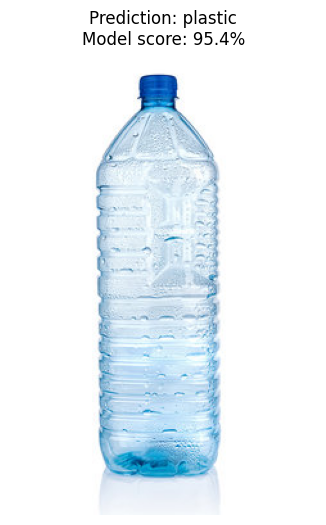

Top three predictions:
plastic      95.39%
glass        4.48%
metal        0.09%


In [4]:
IMAGE_PATH = PROJECT_ROOT / "sample_images" / "bottle.jpg"

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

with Image.open(IMAGE_PATH) as source:
    # Respect camera orientation and convert to three colour channels.
    picture = ImageOps.exif_transpose(source).convert("RGB")

# Use the same resizing, cropping and normalization as evaluation.
image_tensor = transform(picture).unsqueeze(0).to(device)

with torch.inference_mode():
    logits = model(image_tensor)
    scores = torch.softmax(logits, dim=1)[0].cpu()
    top_scores, top_indices = scores.topk(3)

predicted_class = class_names[top_indices[0].item()]

plt.figure(figsize=(6, 6))
plt.imshow(picture)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Model score: {top_scores[0].item():.1%}"
)
plt.axis("off")
plt.show()

print("Top three predictions:")
for score, index in zip(top_scores, top_indices):
    print(f"{class_names[index.item()]:12s} {score.item():.2%}")